In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

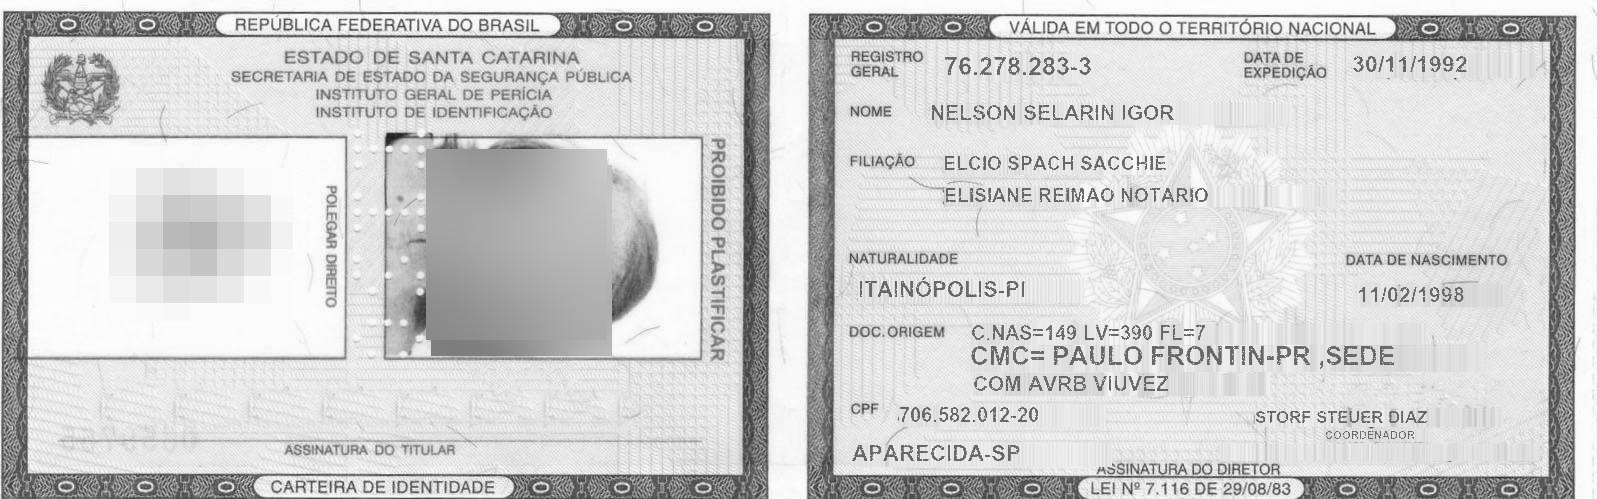

In [ ]:
image = cv2.imread('/content/drive/MyDrive/ComputerVision/IdsDataset/00018418_in.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

In [ ]:
blur = cv2.blur(gray, (3,3))
blur = cv2.medianBlur(blur, 3)

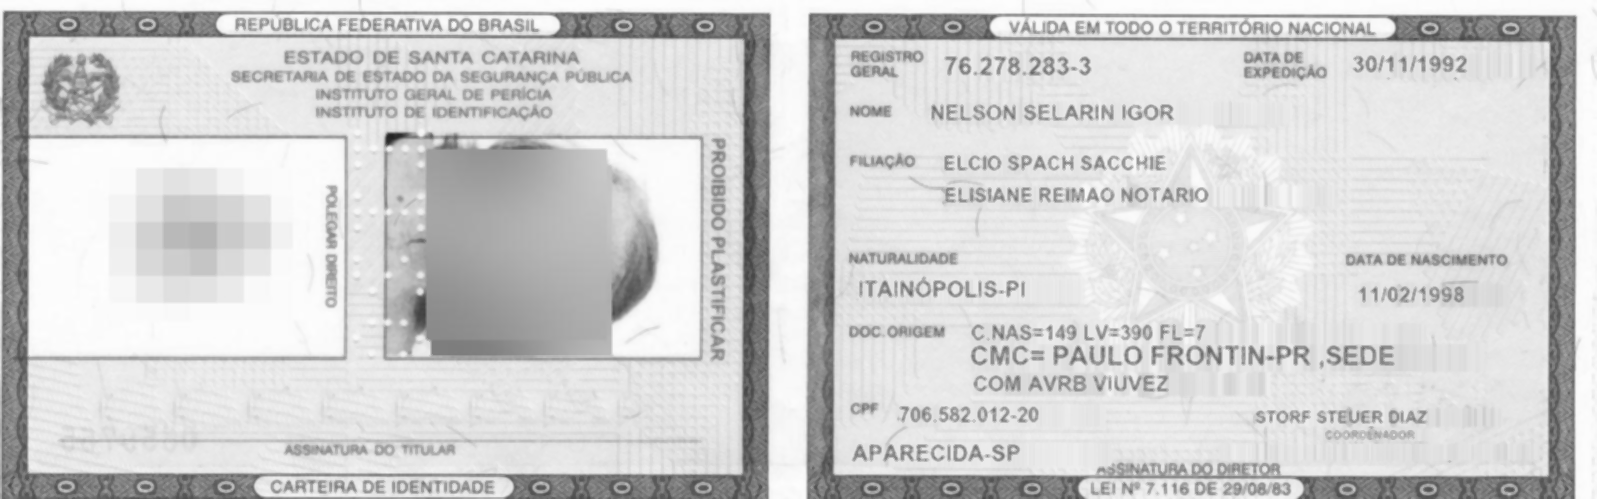

In [ ]:
cv2_imshow(blur)

In [ ]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20.0, 20.0)

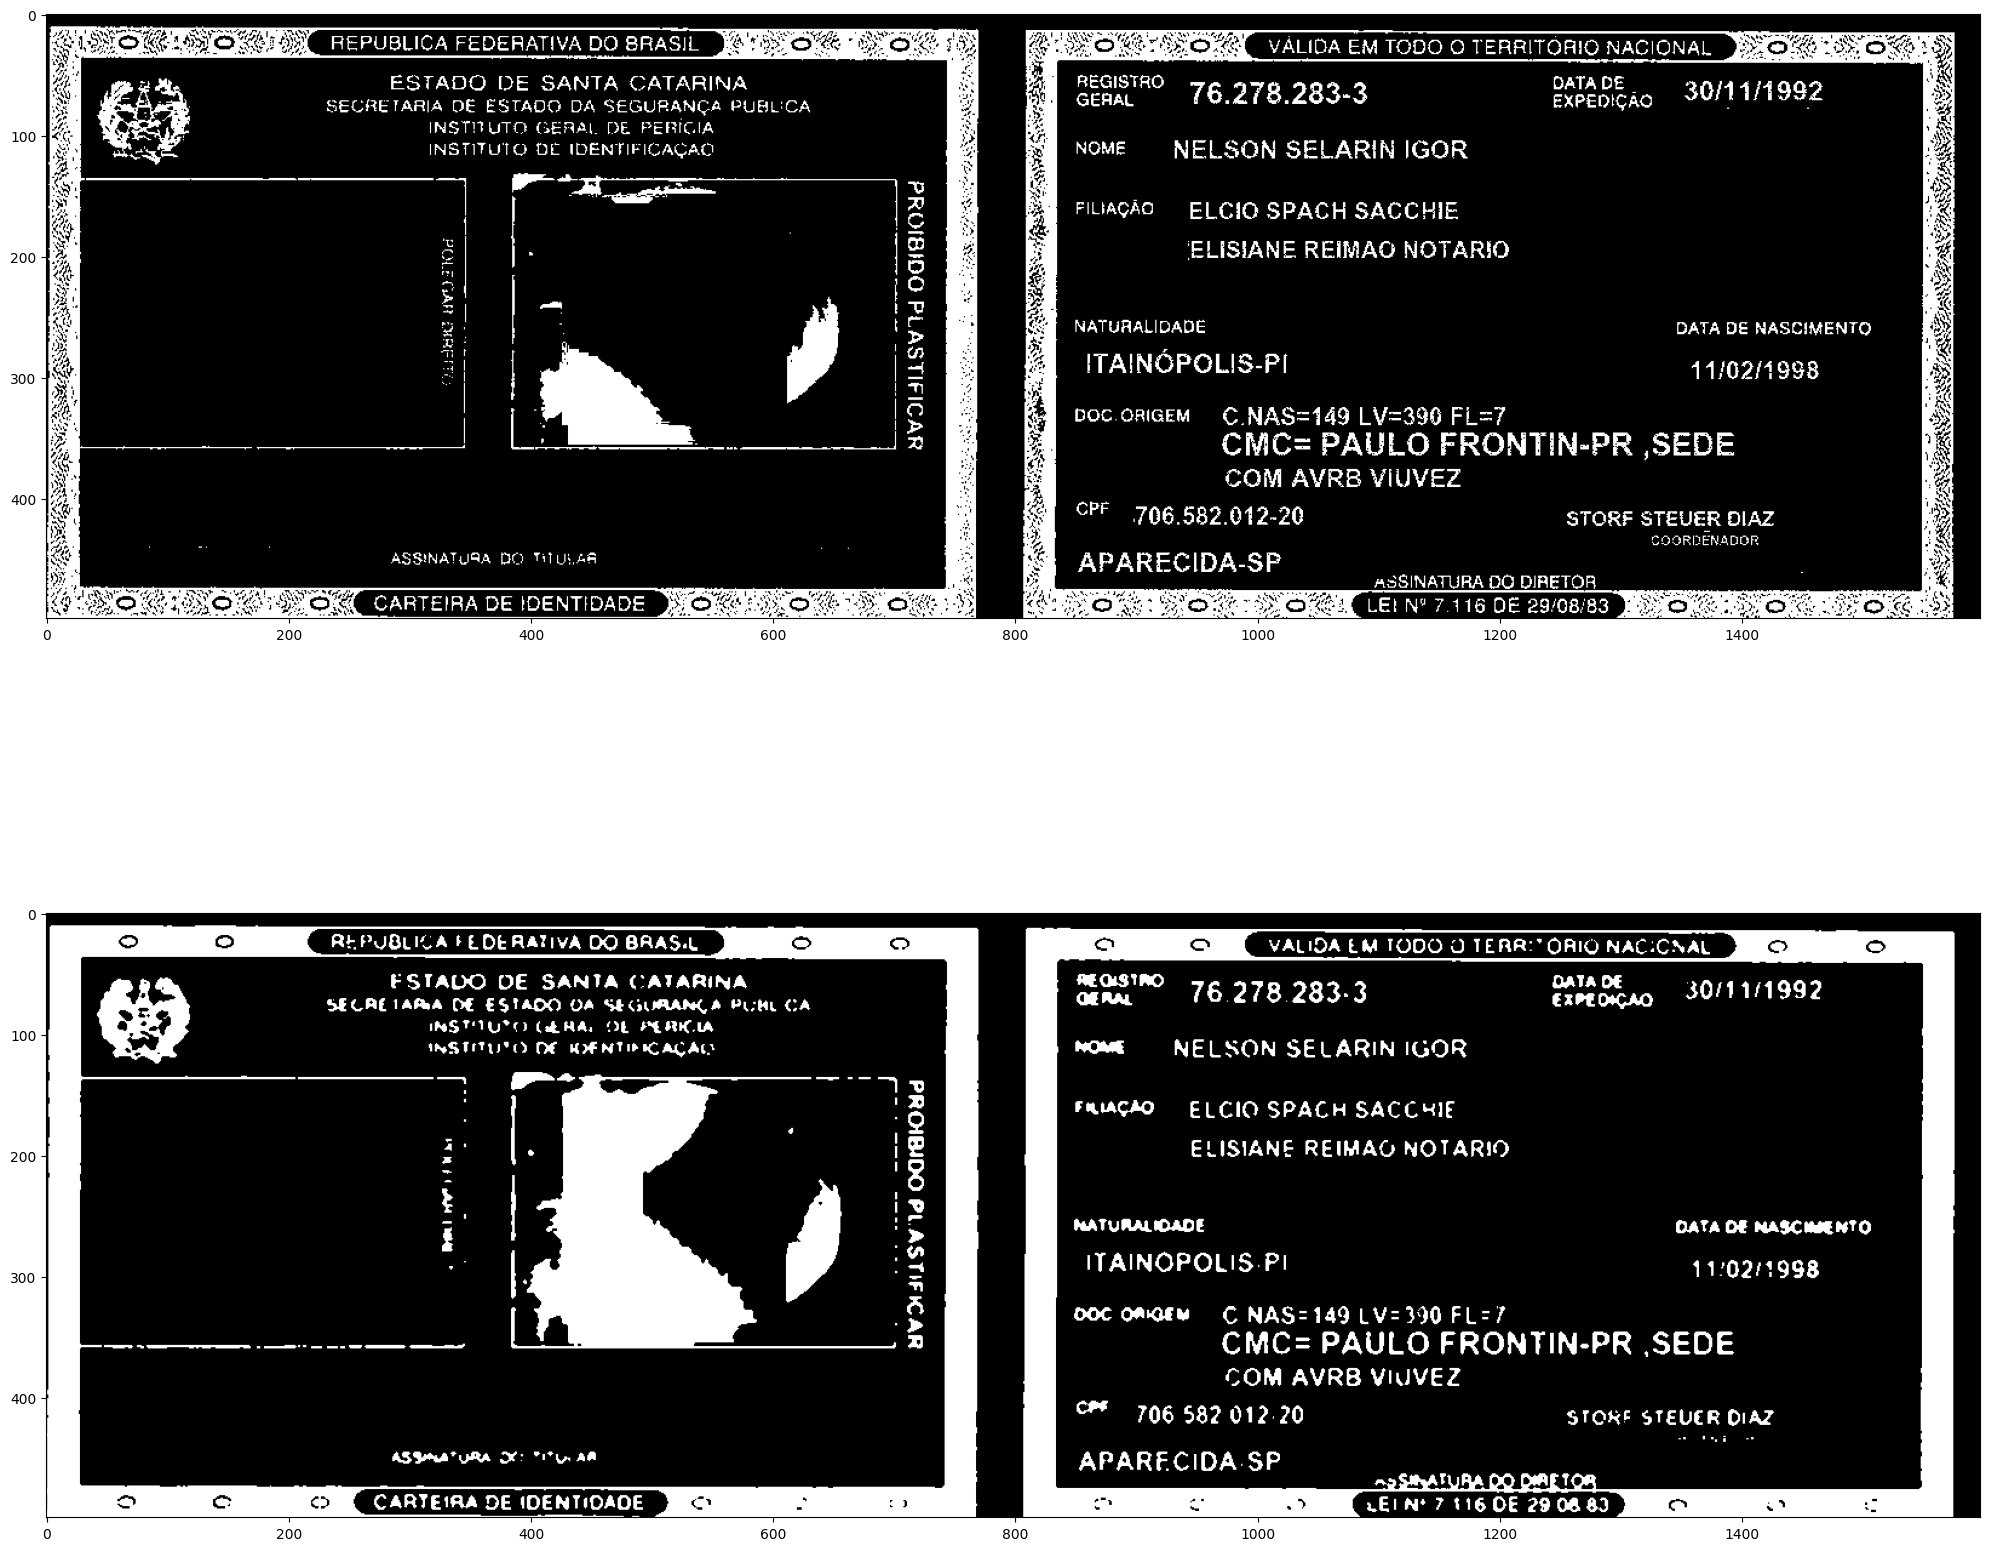

In [ ]:
binary_image = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)[1]
binary_image_blur = cv2.threshold(blur, 170, 255, cv2.THRESH_BINARY_INV)[1]
#cv2_imshow(binary_image)
plt.subplot(2, 1, 1)
plt.imshow(binary_image, cmap='gray')
plt.subplot(2, 1, 2)
plt.imshow(binary_image_blur, cmap='gray')

plt.tight_layout()
plt.show()

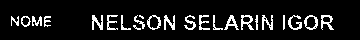

In [ ]:
segment = binary_image[90:130, 840:1200]
cv2_imshow(segment)

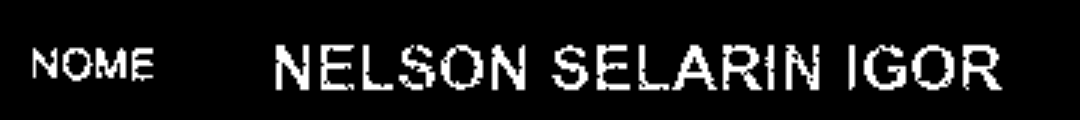

(120, 1080)

In [ ]:
segment = cv2.resize(segment, (1080, 120))
cv2_imshow(segment)
segment.shape

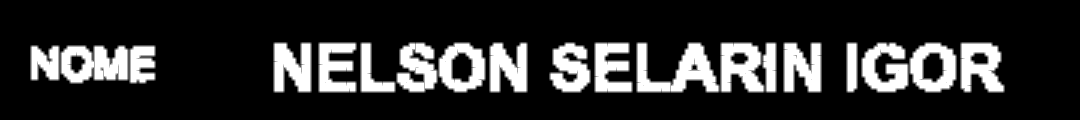

In [ ]:
kernel = np.ones((3,3),np.uint8)
segment = cv2.dilate(segment, kernel, iterations=1)
segment = cv2.dilate(segment, kernel, iterations=1)
cv2_imshow(segment)

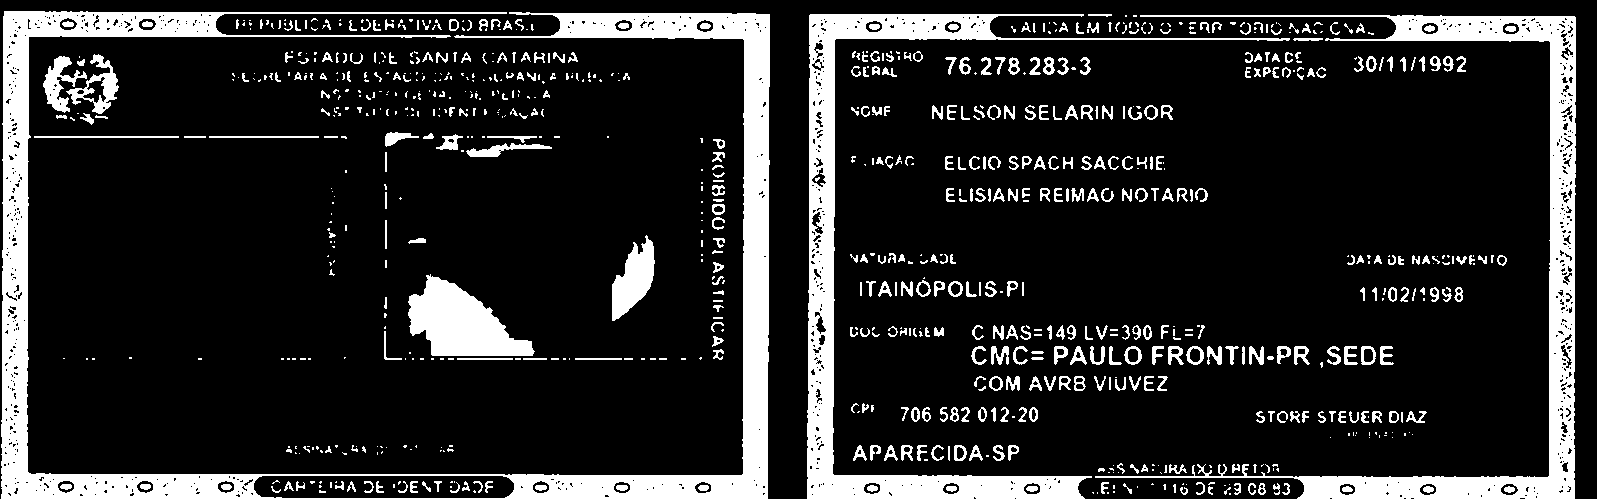

In [ ]:
treated_img = cv2.medianBlur(binary_image, 3)
cv2_imshow(treated_img)

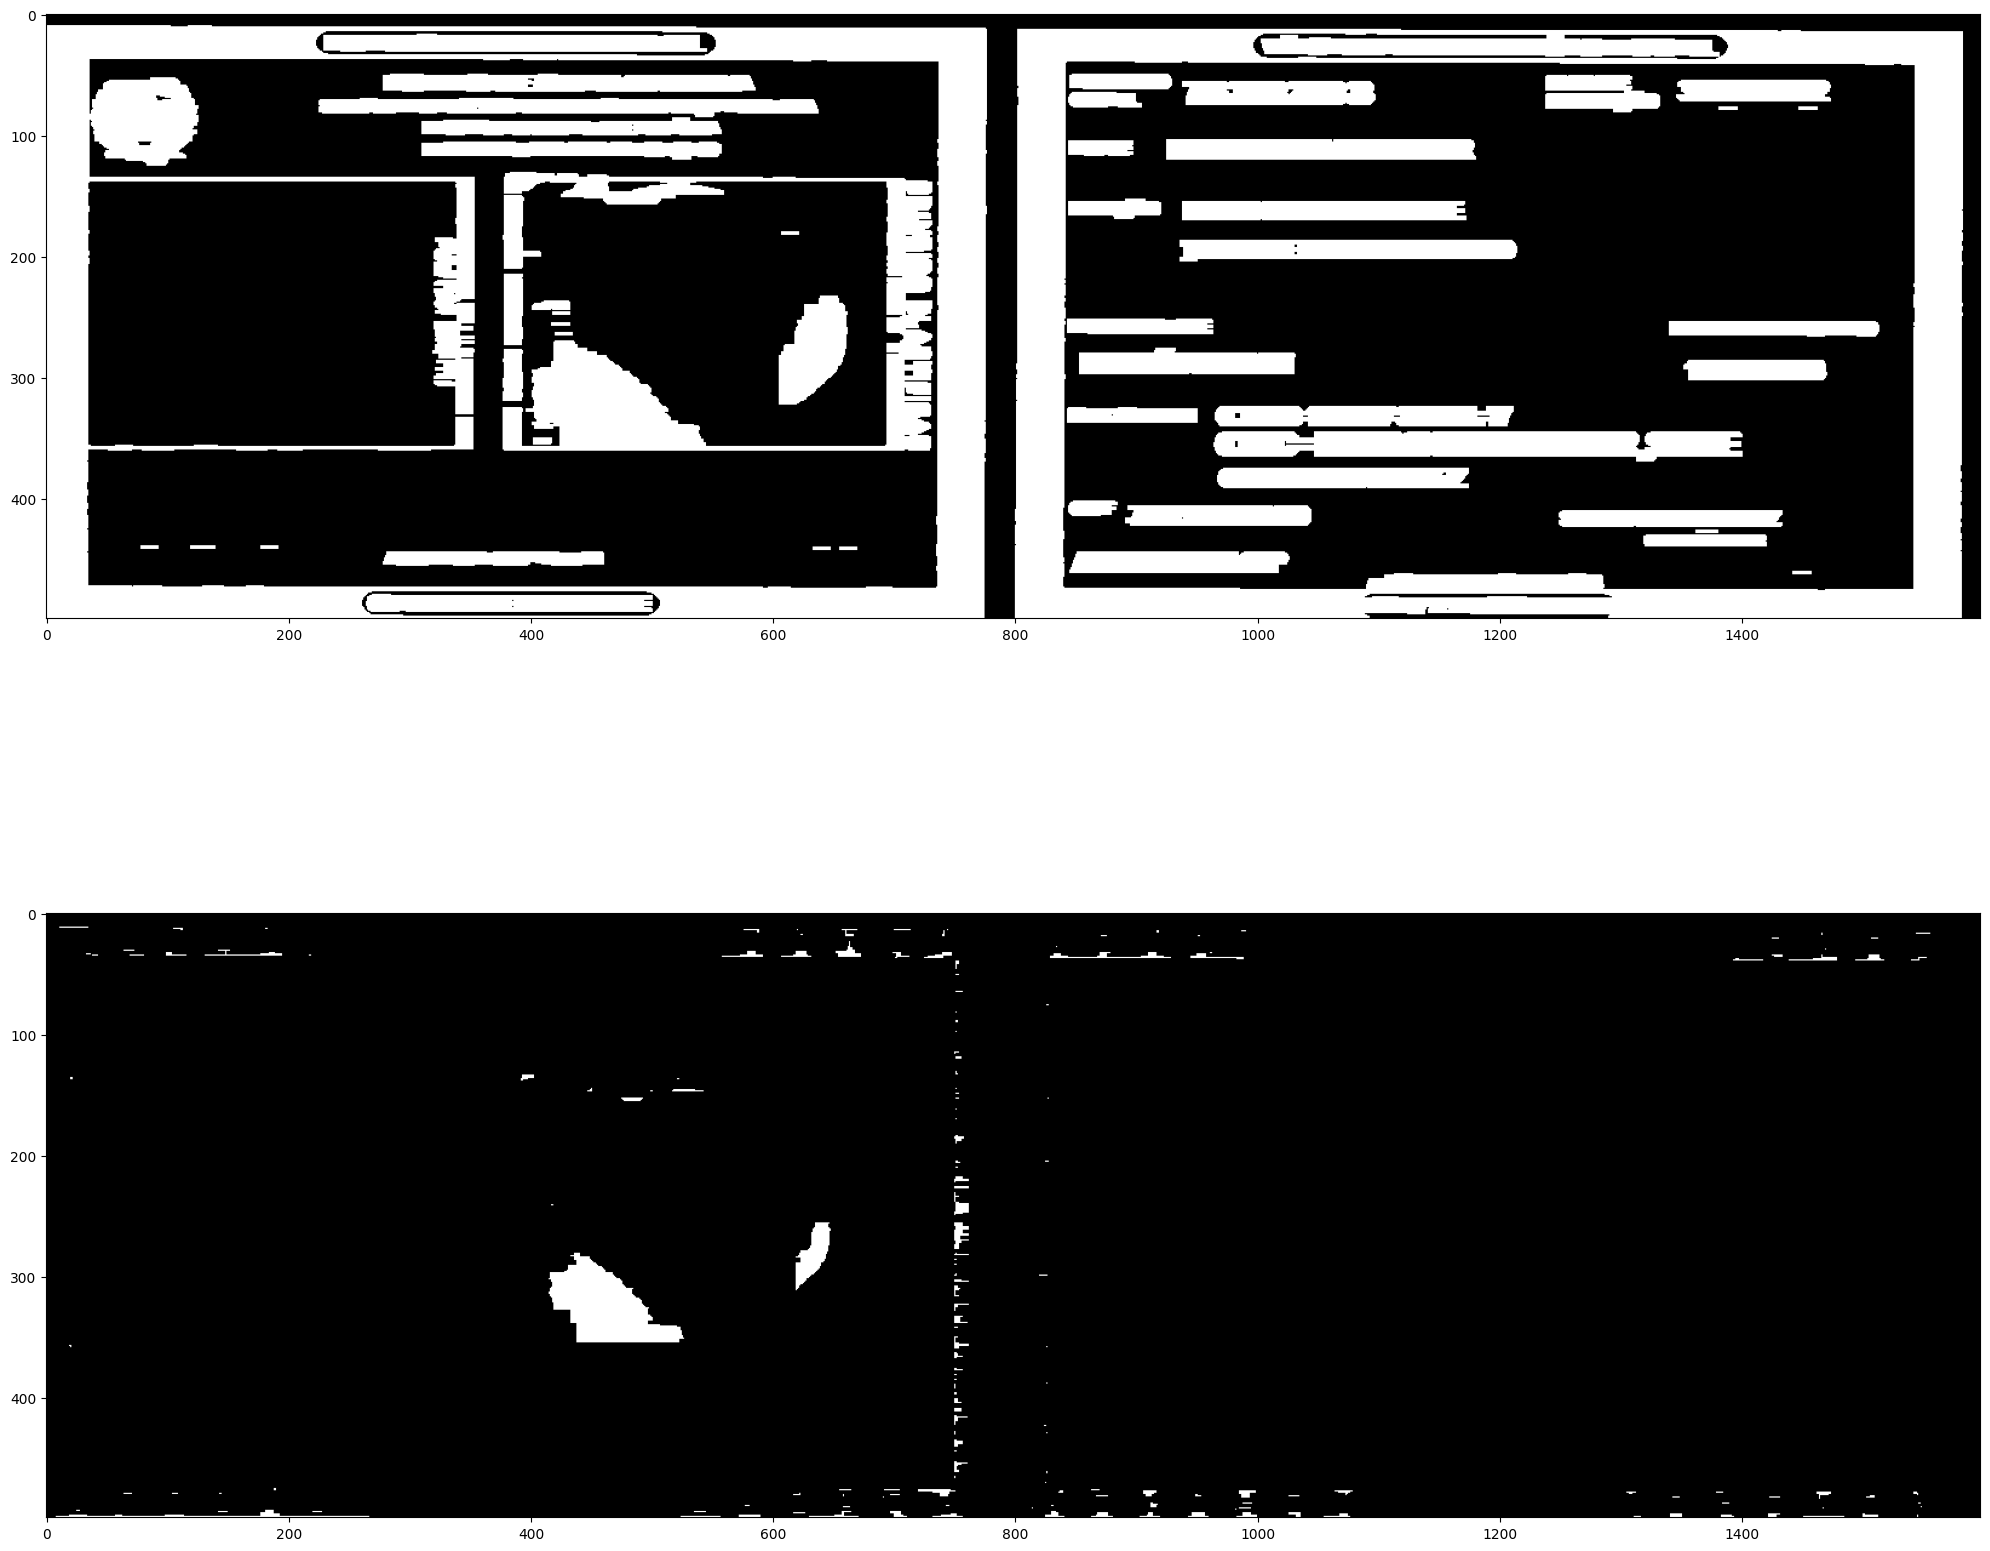

In [ ]:
#kernel = np.ones((3,3),np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
eroded_img = cv2.erode(binary_image, kernel, iterations=1)
dilated_img = cv2.dilate(binary_image, kernel, iterations=1)
#morph_img = cv2.dilate(morph_img, kernel, iterations=1)
#morph_img = cv2.erode(morph_img, kernel, iterations=1)

plt.subplot(2, 1, 1)
plt.imshow(dilated_img, cmap='gray')
plt.subplot(2, 1, 2)
plt.imshow(eroded_img, cmap='gray')

plt.tight_layout()
plt.show()

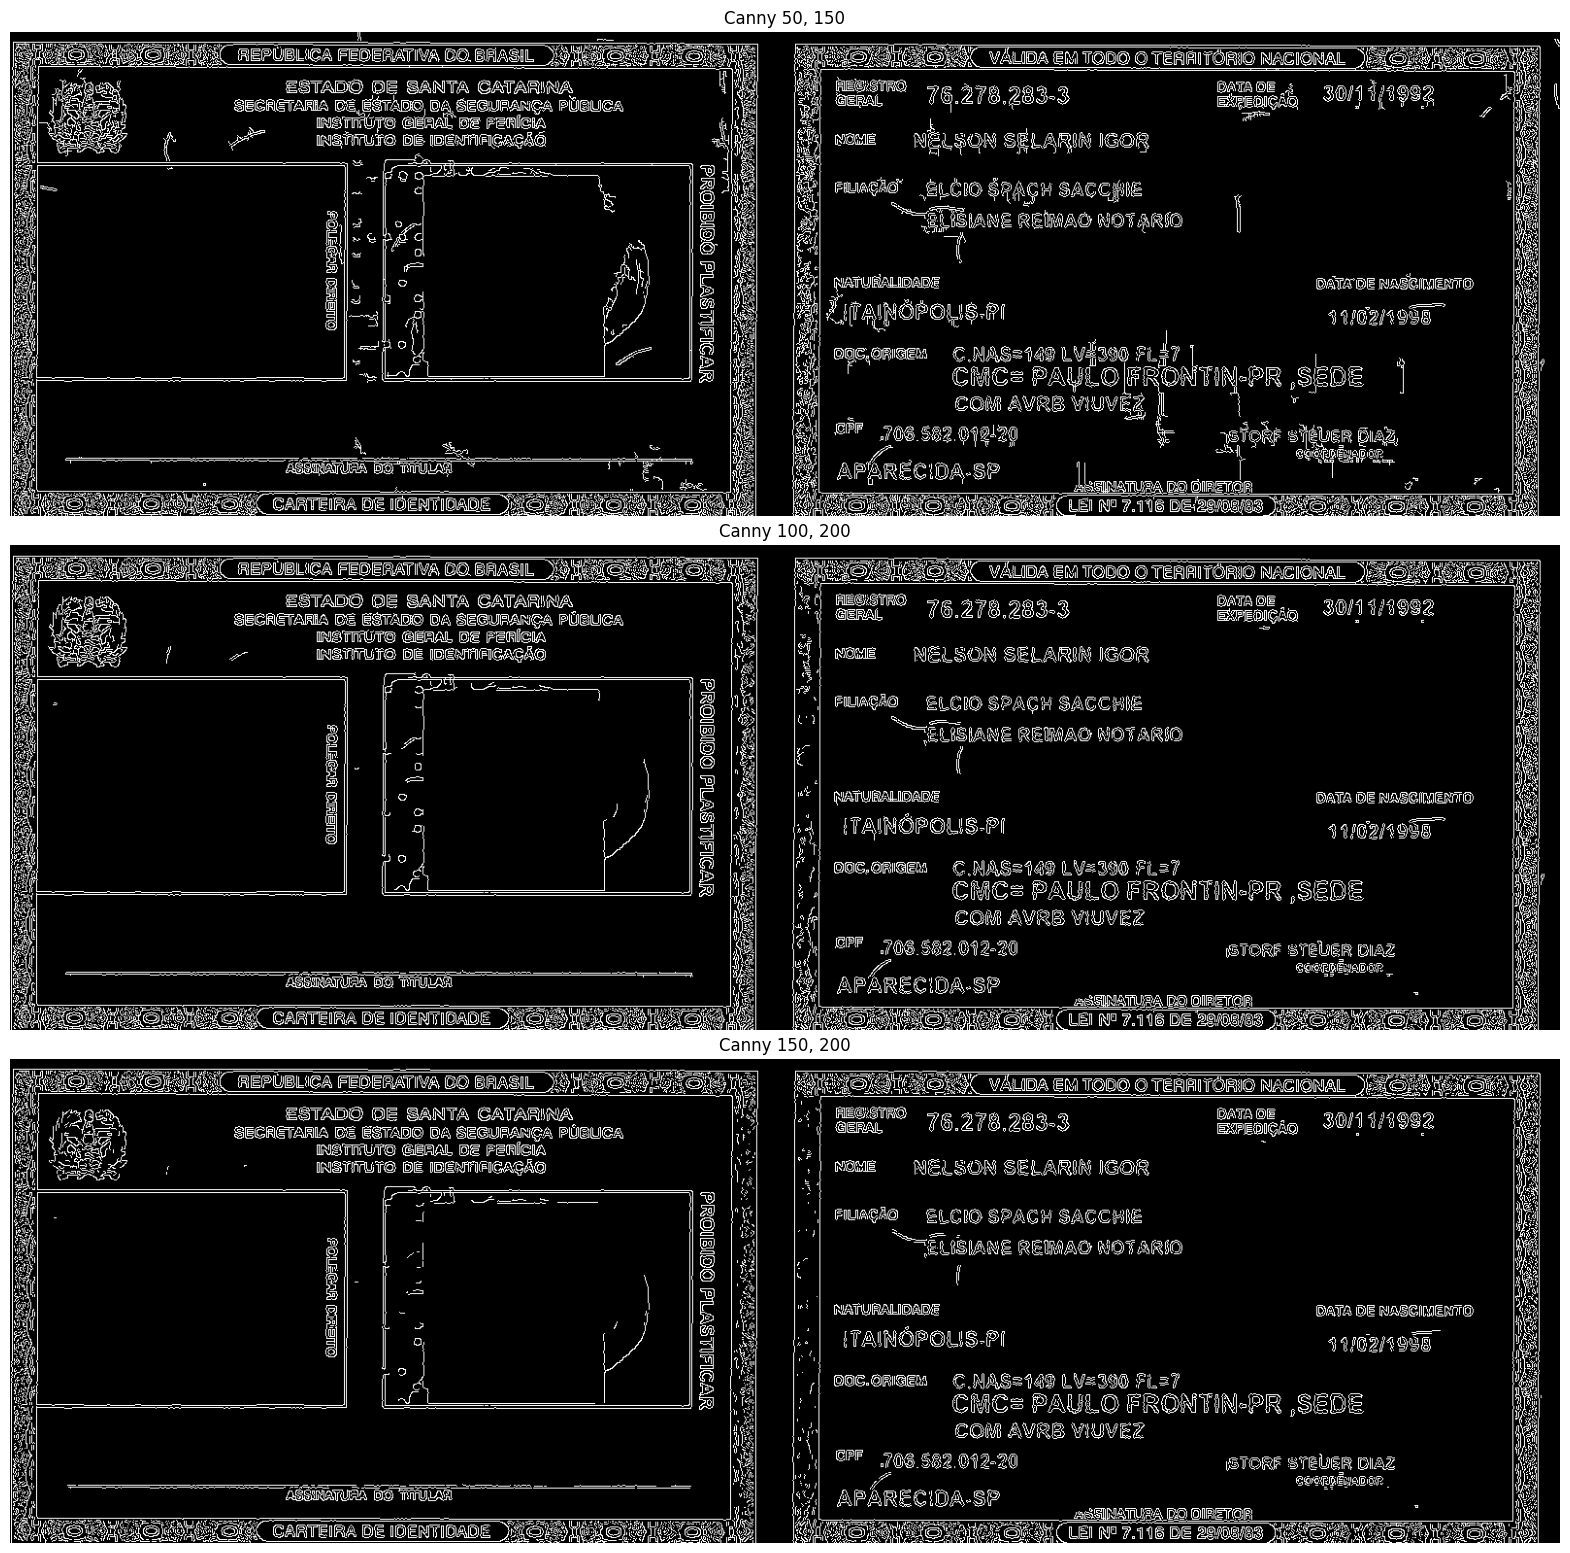

In [ ]:
canny1 = cv2.Canny(gray, 50, 150, L2gradient=True)
canny2 = cv2.Canny(gray, 100, 200, L2gradient=True)
canny3 = cv2.Canny(gray, 150, 200, L2gradient=True)

plt.subplot(3, 1, 1)
plt.imshow(canny1, cmap='gray')
plt.axis('off')
plt.title('Canny 50, 150')
plt.subplot(3, 1, 2)
plt.imshow(canny2, cmap='gray')
plt.axis('off')
plt.title('Canny 100, 200')
plt.subplot(3, 1, 3)
plt.imshow(canny3, cmap='gray')
plt.axis('off')
plt.title('Canny 150, 200')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

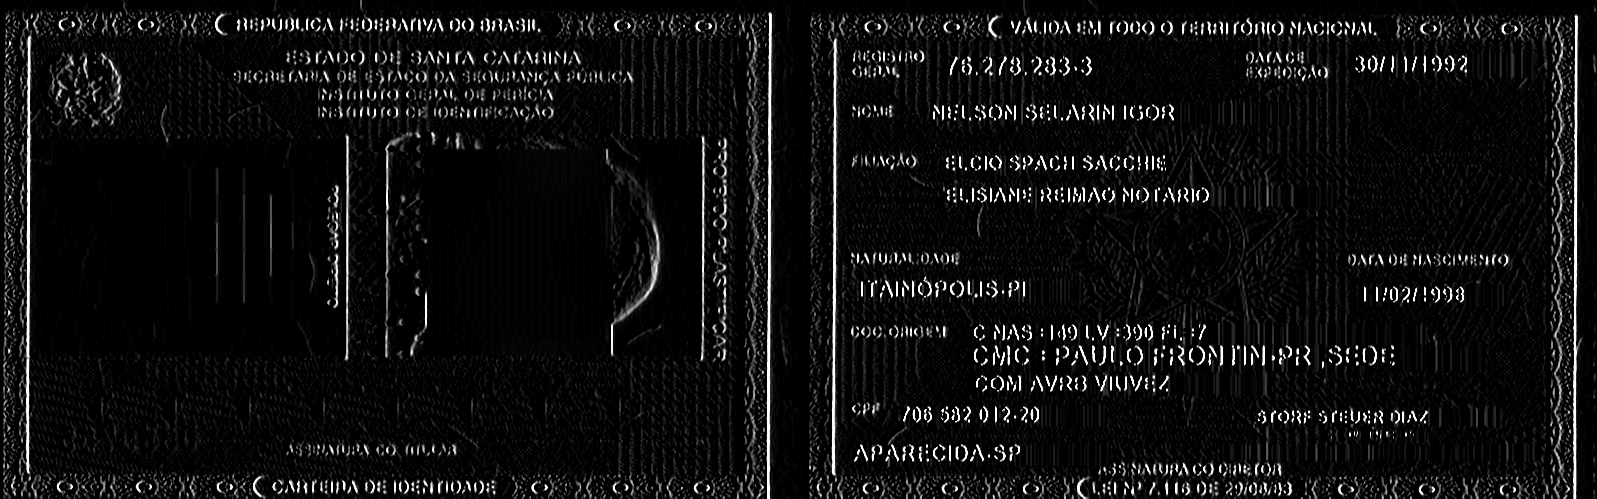

In [ ]:
sobel = cv2.Sobel(blur, cv2.CV_8U, 1, 0, ksize=3)
cv2_imshow(sobel)

In [ ]:
canny.shape

(499, 1597)

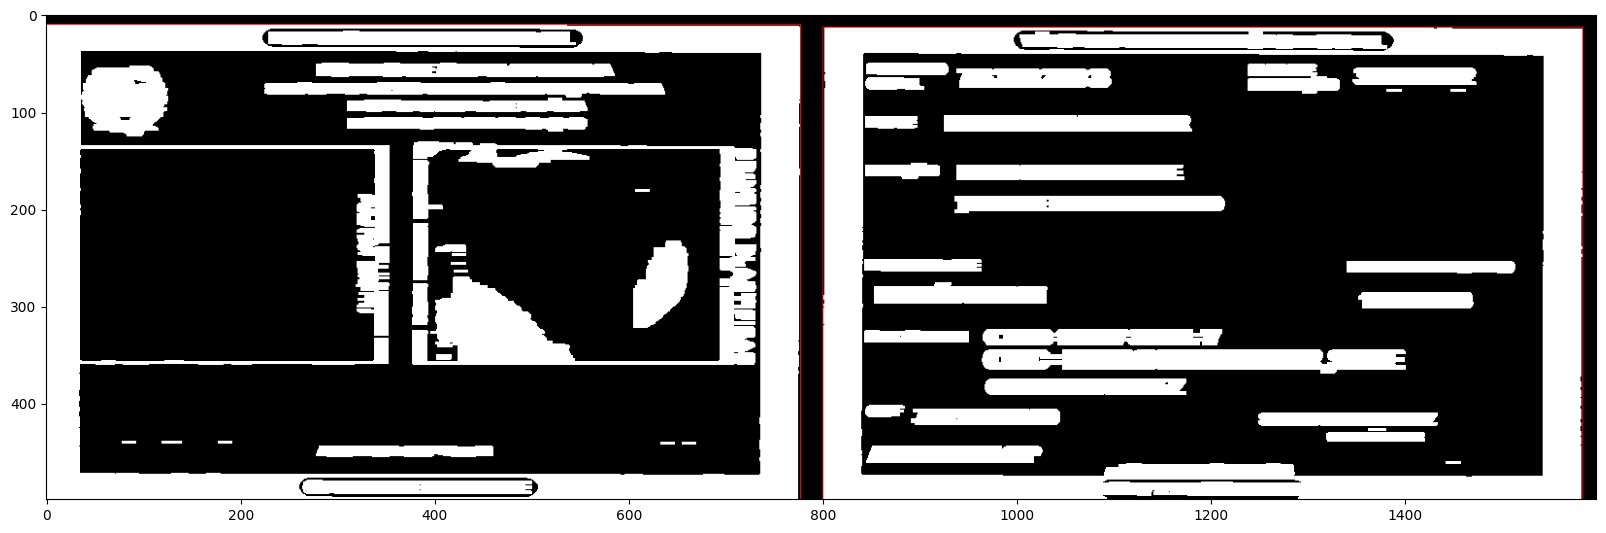

In [ ]:
contours, hierarchy = cv2.findContours(dilated_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

im2 = dilated_img.copy()
im2 = cv2.cvtColor(im2, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(im2, (x,y), (x+w,y+h), (0,0,255), 1)
plt.imshow(im2[:,:,::-1]);

#cv2.drawContours(im2, contours, -1, (0, 0, 255), 1)
#cv2_imshow(im2)

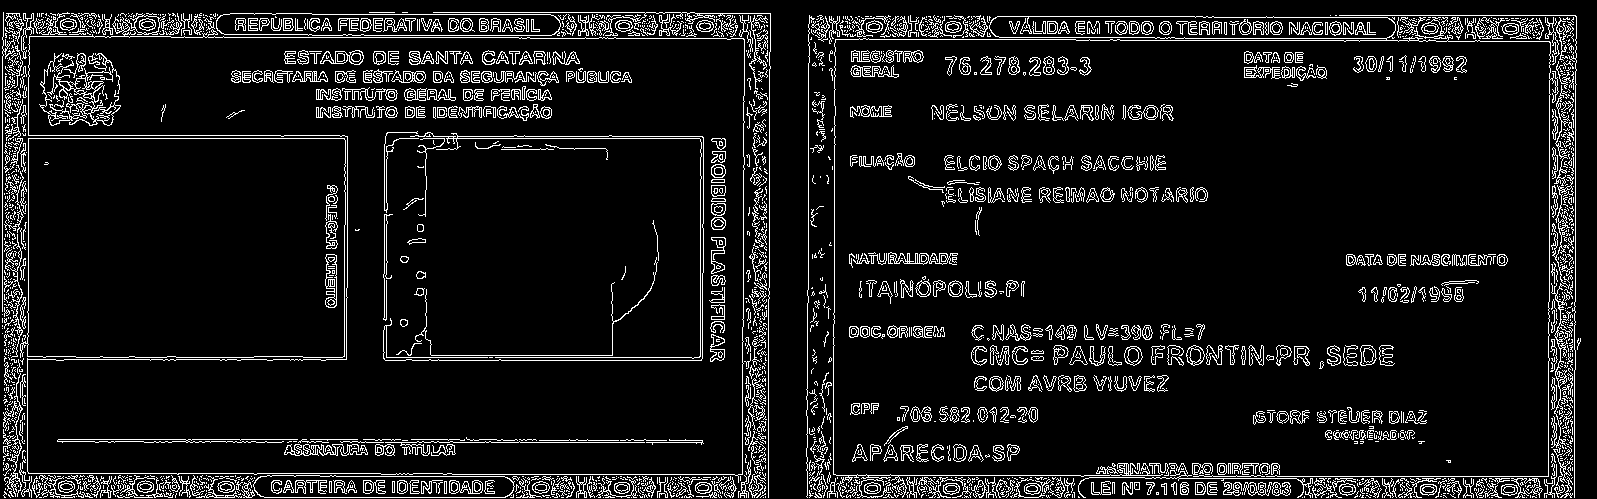

In [ ]:
im2 = canny.copy()
for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(im2, (x, y), (x + w, y + h), (0, 255, 0), 2)
cv2_imshow(im2)

In [ ]:
kernel = np.ones((3,3),np.uint8)
eroded_img = cv2.erode(canny, kernel, iterations=1)
cv2_imshow

<function google.colab.patches.cv2_imshow(a)>

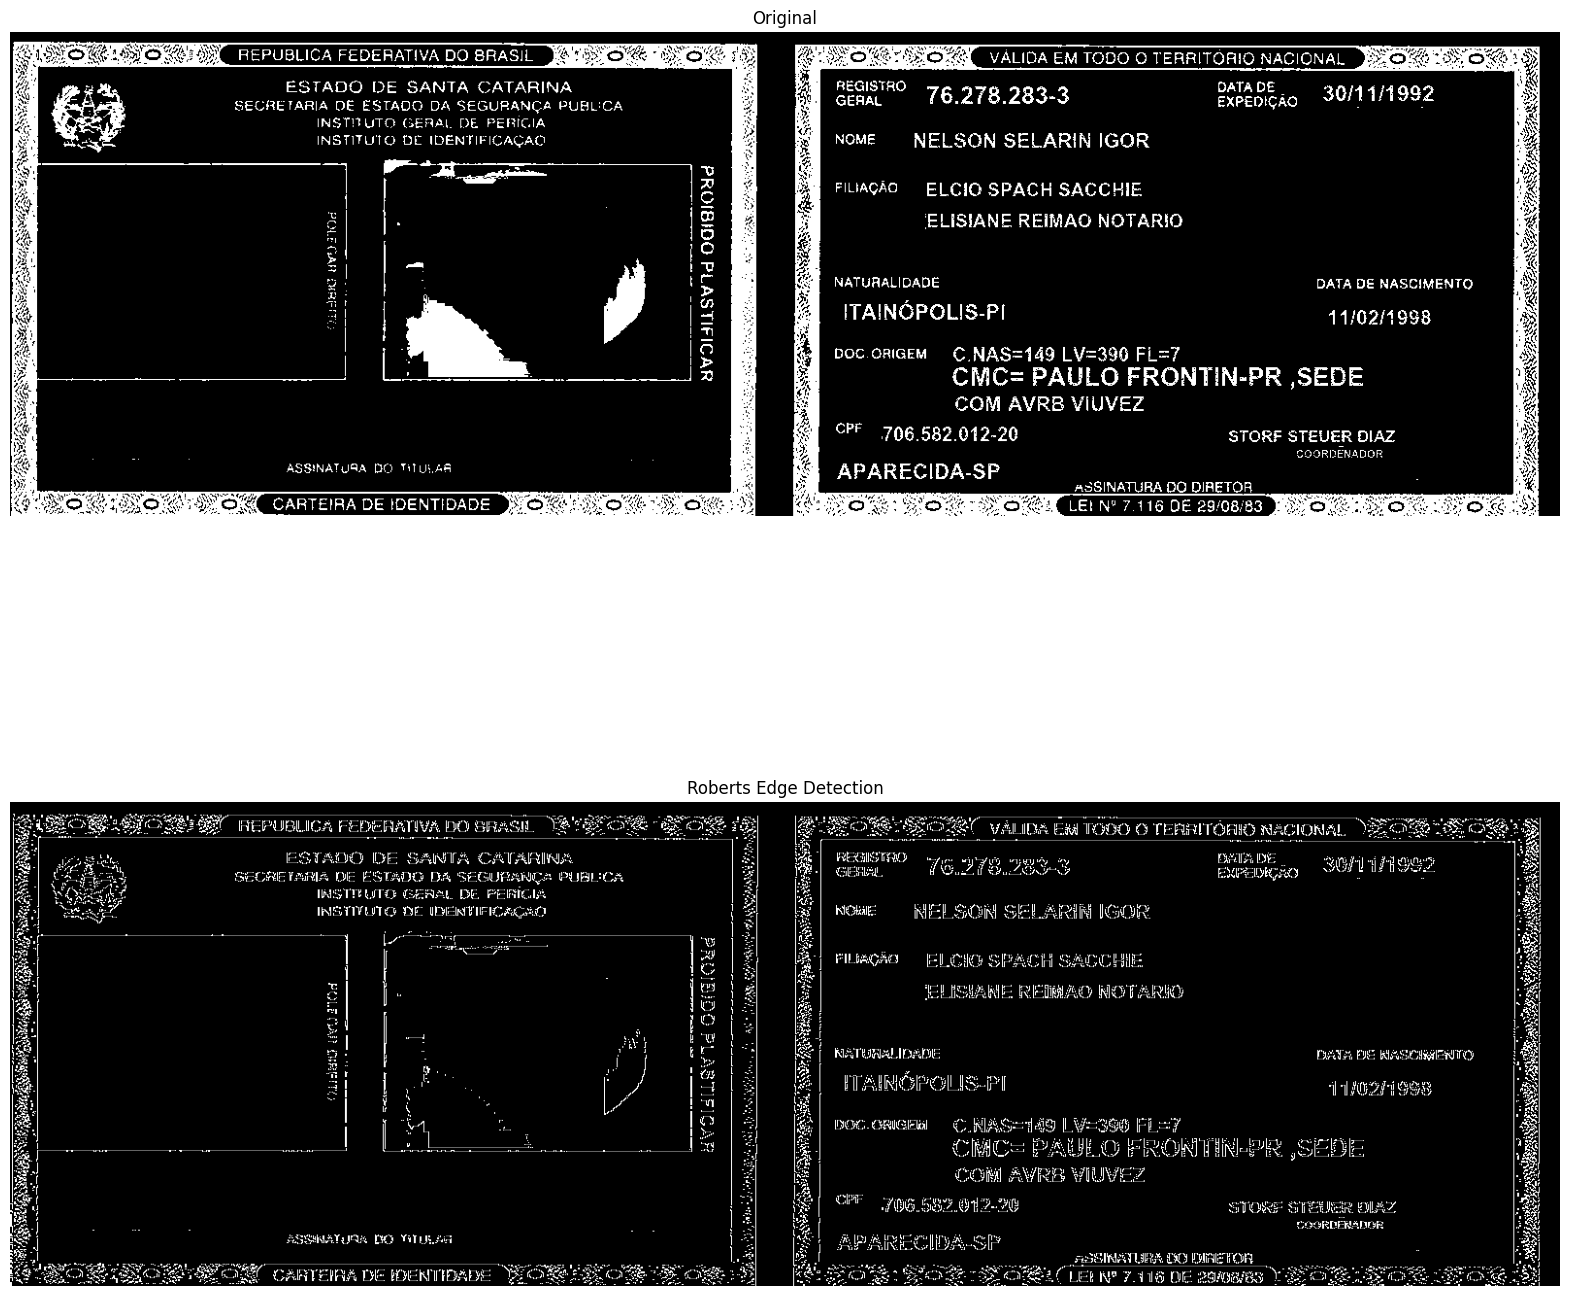

In [ ]:
kernel_x = np.array([[1, 0],
                     [0, -1]], dtype=np.float32)

kernel_y = np.array([[0, 1],
                     [-1, 0]], dtype=np.float32)

# Apply filters
gx = cv2.filter2D(binary_image, -1, kernel_x)
gy = cv2.filter2D(binary_image, -1, kernel_y)

# Combine gradients
roberts = cv2.sqrt(np.square(gx.astype(np.float32)) + np.square(gy.astype(np.float32)))
roberts = np.uint8(roberts)

# Show result
plt.figure(figsize=(20, 20))
plt.subplot(2, 1, 1)
plt.imshow(binary_image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()